# Experiment 5 — Image-Adaptive SLIC Superpixels vs Grid Superpixels

**Motivation**: Stage 1 used a regular grid of rectangular superpixel regions as the  
spatial component of the basis. This approximation is model-agnostic and image-agnostic —  
it does not trace object boundaries.

**SLIC** (Simple Linear Iterative Clustering) segments the image into K compact regions  
using k-means in the 5D CIELAB+spatial space. Each cluster follows object boundaries,  
so SLIC basis vectors perturb semantically coherent regions that classifiers respond to.

**Hypothesis**: better basis projection quality (subspace covers more of the adversarial  
boundary neighborhood) → fewer subspace dimensions needed → faster covariance adaptation.

## Comparison

| Basis | Spatial component | Image-adaptive? |
|---|---|---|
| DCT + grid (Stage 1) | Regular rectangles | No |
| DCT + SLIC (this exp) | SLIC segments | Yes |

Both at k≈40 (20 DCT + 20 spatial), λ=10, budget 1000.

In [3]:
import os
import sys
from pathlib import Path

_candidates = [Path.cwd(), Path.cwd()/'STAGE_2', Path.cwd()/'Adversial ML'/'STAGE_2']
for _p in _candidates:
    if (_p / 'utils_stage2.py').exists():
        sys.path.insert(0, str(_p.resolve())); break
else:
    raise FileNotFoundError('utils_stage2.py not found')

import numpy as np
import torch
import matplotlib.pyplot as plt
from skimage.segmentation import slic as skimage_slic
from skimage.color import label2rgb

from utils_stage2 import (
    clip01, compute_ssim, compute_l2, compute_linf,
    Oracle, load_models, get_jointly_correct,
    phase1, phase2,
    build_dct_basis, build_grid_basis, build_subspace,
    sep_cmaes,
    LINF_THRESHOLD, SSIM_STOP, H, W, C, N_QUICK, RANDOM_SEED,
)

np.random.seed(RANDOM_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

K_DCT = 20    # DCT vectors (shared between both bases)
K_SP  = 20    # spatial vectors
LAM   = 10
P3_BUDGET = 1000
os.makedirs('outputs/exp5', exist_ok=True)

Device: cpu


In [4]:
model_std, model_rob = load_models(device)
images = get_jointly_correct(model_std, model_rob, device, n=N_QUICK)
print(f'Images loaded: {len(images)}')

Images loaded: 30


## SLIC basis construction

For each image:
1. Segment via SLIC into K superpixels (skimage, CIELAB color + spatial).
2. Build K basis vectors: each vector = 1 for pixels in segment i, 0 elsewhere,  
   all three channels, then L2-normalise.
3. Combine with the DCT vectors and QR-orthogonalise.

Because the SLIC segmentation is image-specific, the basis changes per image.

In [5]:
def build_slic_basis(img_hwc, k_dct=20, k_sp=20,
                     H=32, W=32, C=3,
                     compactness=10.0):
    """
    Build DC-free DCT + SLIC superpixel basis for a specific image.
    Returns (B, segments) where B is (k, n) orthonormal and
    segments is the (H, W) label array from SLIC.
    """
    # SLIC segmentation (skimage handles CIELAB conversion internally)
    segments = skimage_slic(
        img_hwc,
        n_segments=k_sp,
        compactness=compactness,
        channel_axis=2,
        start_label=0,
        convert2lab=True,
    )   # shape (H, W), values 0..K_actual-1

    n = H * W * C
    K_actual = segments.max() + 1

    # Build superpixel basis vectors
    sp_vecs = []
    for seg_id in range(K_actual):
        mask = (segments == seg_id)   # (H, W) bool
        if mask.sum() == 0:
            continue
        v = np.zeros((H, W, C), dtype=np.float32)
        v[mask, :] = 1.0              # uniform perturbation within segment
        v_flat = v.flatten()
        nrm = np.linalg.norm(v_flat)
        if nrm > 1e-12:
            sp_vecs.append(v_flat / nrm)

    B_sp = np.array(sp_vecs[:k_sp], dtype=np.float32)

    # DCT basis (same for all images)
    B_dct = build_dct_basis(k_dct=k_dct, H=H, W=W, C=C)

    # Combine and QR-orthogonalise
    B_raw = np.vstack([B_dct, B_sp]).astype(np.float64)
    Q, _  = np.linalg.qr(B_raw.T)
    B     = Q.T[:B_raw.shape[0]].astype(np.float32)

    return B, segments

## Visualise SLIC segmentations

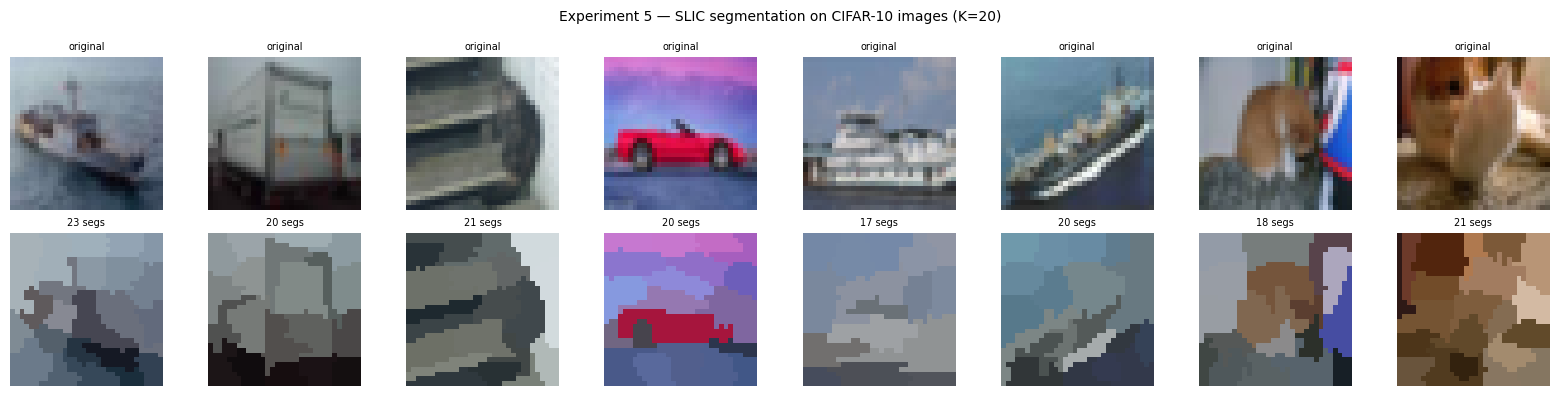

In [6]:
n_show = min(8, len(images))
fig, axes = plt.subplots(2, n_show, figsize=(2*n_show, 4))

for col, rec in enumerate(images[:n_show]):
    img = rec['img']  # HWC float32
    _, segs = build_slic_basis(img, k_dct=K_DCT, k_sp=K_SP)

    axes[0][col].imshow(np.clip(img, 0, 1))
    axes[0][col].set_title(f'original', fontsize=7)
    axes[0][col].axis('off')

    seg_overlay = label2rgb(segs, img, kind='avg', bg_label=-1)
    axes[1][col].imshow(np.clip(seg_overlay, 0, 1))
    axes[1][col].set_title(f'{segs.max()+1} segs', fontsize=7)
    axes[1][col].axis('off')

plt.suptitle('Experiment 5 — SLIC segmentation on CIFAR-10 images (K=20)', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/exp5/slic_segmentations.png', dpi=150)
plt.show()

## Subspace projection quality diagnostic

For each image and each basis, compute how well the Phase-2 boundary delta  
(the adversarial direction we want to optimise) projects onto the subspace.  
Better projection → Phase 3 starts closer to the true boundary direction.

In [7]:
proj_grid  = []   # {'img_idx', 'grid_proj', 'slic_proj', 'n_slic_segs'}
B_grid_ref = build_subspace(k_dct=K_DCT, k_sp=K_SP)  # fixed grid basis

print('Computing subspace projection quality ...')
for rec in images:
    o = Oracle(model_std, rec['label'], device)
    xb, winner = phase1(o, rec['img'], seed=rec['idx'])
    if xb is None:
        continue
    xb = phase2(o, rec['img'], xb)
    delta = xb.flatten() - rec['img'].flatten()   # adversarial direction
    delta_norm = np.linalg.norm(delta)
    if delta_norm < 1e-12:
        continue
    delta_unit = delta / delta_norm

    # Grid basis projection
    theta_grid = B_grid_ref @ delta_unit
    proj_grid_val = float(np.linalg.norm(theta_grid))

    # SLIC basis projection (image-specific)
    B_slic, segs = build_slic_basis(rec['img'], k_dct=K_DCT, k_sp=K_SP)
    theta_slic = B_slic @ delta_unit
    proj_slic_val = float(np.linalg.norm(theta_slic))

    proj_grid.append(dict(
        img_idx=rec['idx'],
        grid_proj=proj_grid_val,
        slic_proj=proj_slic_val,
        n_segs=segs.max()+1,
    ))

# A projection of 1.0 means the delta lies perfectly within the subspace.
# Higher is better.
grid_p = [r['grid_proj'] for r in proj_grid]
slic_p = [r['slic_proj'] for r in proj_grid]
print(f'Grid projection: mean={np.mean(grid_p):.4f}  median={np.median(grid_p):.4f}')
print(f'SLIC projection: mean={np.mean(slic_p):.4f}  median={np.median(slic_p):.4f}')

Computing subspace projection quality ...
Grid projection: mean=0.8010  median=0.8376
SLIC projection: mean=0.9168  median=0.9755


## Run Phase 3 comparison: DCT+grid vs DCT+SLIC

In [8]:
MODELS = [('standard', model_std), ('robust', model_rob)]

results_grid = {m: [] for m, _ in MODELS}
results_slic = {m: [] for m, _ in MODELS}
hists_grid   = {m: [] for m, _ in MODELS}
hists_slic   = {m: [] for m, _ in MODELS}

p12 = {m: {} for m, _ in MODELS}
for model_name, model in MODELS:
    for rec in images:
        o = Oracle(model, rec['label'], device)
        xb, _ = phase1(o, rec['img'], seed=rec['idx'])
        if xb is None:
            p12[model_name][rec['idx']] = None
        else:
            xb = phase2(o, rec['img'], xb)
            p12[model_name][rec['idx']] = xb

print('Phase 1+2 done.')

Phase 1+2 done.


In [9]:
for model_name, model in MODELS:
    print(f'\n=== {model_name.upper()} ===')
    for rec in images:
        xb = p12[model_name].get(rec['idx'])
        if xb is None:
            results_grid[model_name].append(None)
            results_slic[model_name].append(None)
            hists_grid[model_name].append([])
            hists_slic[model_name].append([])
            continue

        l2_p2 = compute_l2(rec['img'], xb)

        # --- Grid basis ---
        o_g = Oracle(model, rec['label'], device)
        bx_g, bl2_g, bss_g, q_g, hist_g = sep_cmaes(
            o_g, rec['img'], xb, B_grid_ref,
            lam=LAM, max_queries=P3_BUDGET)
        results_grid[model_name].append(
            dict(l2_p2=l2_p2, l2_p3=bl2_g, ssim=bss_g,
                 improvement=l2_p2-bl2_g, q=q_g))
        hists_grid[model_name].append(hist_g)

        # --- SLIC basis (image-specific) ---
        B_slic, _ = build_slic_basis(rec['img'], k_dct=K_DCT, k_sp=K_SP)
        o_s = Oracle(model, rec['label'], device)
        bx_s, bl2_s, bss_s, q_s, hist_s = sep_cmaes(
            o_s, rec['img'], xb, B_slic,
            lam=LAM, max_queries=P3_BUDGET)
        results_slic[model_name].append(
            dict(l2_p2=l2_p2, l2_p3=bl2_s, ssim=bss_s,
                 improvement=l2_p2-bl2_s, q=q_s))
        hists_slic[model_name].append(hist_s)

    vg = [r for r in results_grid[model_name] if r]
    vs = [r for r in results_slic[model_name] if r]
    print(f'  Grid: med L2={np.median([r["l2_p3"] for r in vg]):.4f}  '
          f'med imp={np.median([r["improvement"] for r in vg]):.4f}')
    print(f'  SLIC: med L2={np.median([r["l2_p3"] for r in vs]):.4f}  '
          f'med imp={np.median([r["improvement"] for r in vs]):.4f}')


=== STANDARD ===
  Grid: med L2=2.5899  med imp=2.0026
  SLIC: med L2=2.9232  med imp=0.4315

=== ROBUST ===
  Grid: med L2=3.6922  med imp=4.9632
  SLIC: med L2=4.2823  med imp=4.3096


## Plots

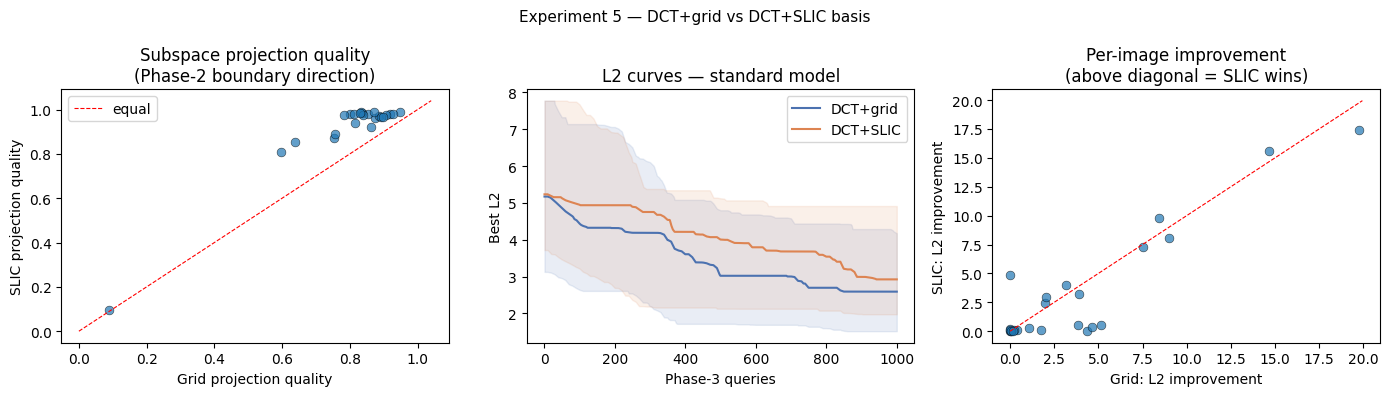

Experiment 5 complete. Outputs saved to outputs/exp5/


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1 — Projection quality scatter
ax = axes[0]
ax.scatter(grid_p, slic_p, alpha=0.7, edgecolors='k', lw=0.4, s=40)
lim = max(max(grid_p), max(slic_p)) + 0.05
ax.plot([0, lim], [0, lim], 'r--', lw=0.8, label='equal')
ax.set_xlabel('Grid projection quality')
ax.set_ylabel('SLIC projection quality')
ax.set_title('Subspace projection quality\n(Phase-2 boundary direction)')
ax.legend()

# Panel 2 — L2 curves (standard model)
ax = axes[1]
for hists, lbl, color in [
    (hists_grid['standard'], 'DCT+grid', '#4C72B0'),
    (hists_slic['standard'], 'DCT+SLIC', '#DD8452')
]:
    valid = [h for h in hists if h]
    if not valid:
        continue
    q_max  = max(h[-1]['queries'] for h in valid)
    q_grid = np.arange(1, q_max + 1)
    curves = [np.interp(q_grid,
                        [hh['queries'] for hh in h],
                        [hh['best_l2'] for hh in h]) for h in valid]
    arr = np.array(curves)
    ax.plot(q_grid, np.median(arr, 0), label=lbl, color=color)
    ax.fill_between(q_grid, np.percentile(arr, 25, 0),
                    np.percentile(arr, 75, 0), alpha=0.12, color=color)
ax.set_xlabel('Phase-3 queries')
ax.set_ylabel('Best L2')
ax.set_title('L2 curves — standard model')
ax.legend()

# Panel 3 — Per-image improvement scatter (SLIC vs grid)
ax = axes[2]
imp_g = [r['improvement'] for r in results_grid['standard'] if r]
imp_s = [r['improvement'] for r in results_slic['standard'] if r]
n = min(len(imp_g), len(imp_s))
ax.scatter(imp_g[:n], imp_s[:n], alpha=0.7, edgecolors='k', lw=0.4, s=40)
lim = max(max(imp_g[:n]), max(imp_s[:n])) + 0.2
ax.plot([0, lim], [0, lim], 'r--', lw=0.8)
ax.set_xlabel('Grid: L2 improvement')
ax.set_ylabel('SLIC: L2 improvement')
ax.set_title('Per-image improvement\n(above diagonal = SLIC wins)')

plt.suptitle('Experiment 5 — DCT+grid vs DCT+SLIC basis', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/exp5/grid_vs_slic.png', dpi=150)
plt.show()
print('Experiment 5 complete. Outputs saved to outputs/exp5/')